In [1]:
VERSION

v"1.12.5"

In [2]:
using Plots

In [3]:
using CSV

In [4]:
using DataFrames

In [5]:
using Statistics

# Calibration

In [6]:
calibration_path = "../calibration_0822/"

calib_H = []
calib_V = []

for i in 1:5
    push!(calib_H,
        DataFrame(CSV.File(joinpath(calibration_path, "mesure_faible_HDVAHDVAH_5cm_3_deg_$(i).csv"))))
    push!(calib_V,
        DataFrame(CSV.File(joinpath(calibration_path, "mesure_faible_HDVAHDVAH_5cm_48_deg_$(i).csv"))))
end

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV ~/.julia/packages/CSV/LiiJM/src/file.jl:593
┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV ~/.julia/packages/CSV/LiiJM/src/file.jl:593
┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV ~/.julia/packages/CSV/LiiJM/src/file.jl:593
┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV ~/.julia/packages/CSV/LiiJM/src/file.jl:593
┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ 

In [7]:
time = parse.(Float64, calib_H[1][2:end, 1])
V_H = hcat([
    parse.(Float64, df[2:end, 2])
    for df in calib_H
]...)
mean_voltage_H = vec(mean(V_H, dims=2))
V_V = hcat([
    parse.(Float64, df[2:end, 2])
    for df in calib_V
]...)
mean_voltage_V = vec(mean(V_V, dims=2))

5000-element Vector{Float64}:
 -0.00029040625
 -0.00029128125
 -0.0002889375
 -0.00028828125
 -0.00029268750000000003
 -0.00028918750000000006
 -0.00029278125
 -0.00029128125000000004
 -0.00028859375
 -0.00028965625000000004
 -0.00028909375
 -0.0002921875
 -0.00029090625000000004
  ⋮
 -0.00024868750000000005
 -0.00025062500000000003
 -0.00025015625000000005
 -0.00024828125
 -0.00024918750000000006
 -0.000248125
 -0.00024921875000000004
 -0.0002500625
 -0.00024681249999999996
 -0.00024950000000000005
 -0.000251625
 -0.00025203125

In [8]:
idx = argmax(mean_voltage_H)
calib_H_tpos = time[idx]
idx = argmax(mean_voltage_V)
calib_V_tpos = time[idx]
delay = calib_V_tpos - calib_H_tpos
println("Delay: ", delay*1e12, " ps")

Delay: -255.99999999999912 ps


# HDVA

In [9]:
using Glob

files = glob("mesure_faible_HeNe_5cm_*_deg_*.csv", "measurement3_2806")

degrees = sort(unique(
    parse(Int,
          match(r"_(\d+)_deg_", basename(f)).captures[1]
    )
    for f in files
));

In [10]:
using LsqFit
using SavitzkyGolay

gaussian(t, p) = p[1] .* exp.(-((t .- p[2]).^2) ./ (2p[3]^2)) #.+ p[4]

τ = Float64[]
degs = Float64[]
time = []
Volt = []
for deg in degrees
    
    dfs = DataFrame[]
    
    for i in 1:5
        file = joinpath("measurement3_2806", "mesure_faible_HeNe_5cm_$(deg)_deg_$(i).csv")
        push!(dfs, DataFrame(
                CSV.File(file; header=2)
            )
        )
    end
    
    t = dfs[1][!, "Times/s"]
    push!(time,t)
    # average voltage
    V = hcat([df[!, "Voltage/V"] for df in dfs]...)
    
    Vavg = vec(mean(V, dims=2))

    # derivative
    dVdt = abs.(diff(Vavg) ./ diff(t))
    dVdt = savitzky_golay(dVdt, 21, 3).y
    push!(Volt,dVdt)
    tmid = (t[1:end-1] .+ t[2:end]) ./ 2

    # Find rough peak first
    idx0 = argmax(abs.(dVdt))

    # Take a small window around the peak
    window = 100
    i1 = max(1, idx0 - window)
    i2 = min(length(dVdt), idx0 + window)

    tfit = tmid[i1:i2]
    yfit = dVdt[i1:i2]

    # Initial guesses
    A0 = yfit[argmax(abs.(yfit))]
    t0 = tmid[idx0]
    σ0 = (maximum(tfit) - minimum(tfit)) / 6
    #C0 = mean(yfit)

    p0 = [A0, t0, σ0]

    fit = curve_fit(gaussian, tfit, yfit, p0)

    p = coef(fit)

    t_peak_fit = p[2]
    
    push!(τ, t_peak_fit)
    push!(degs, deg)
end


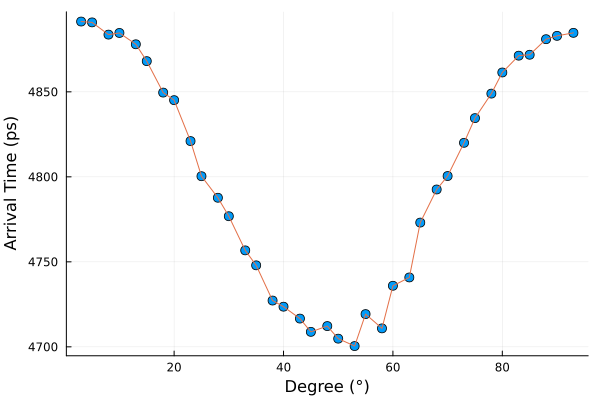

In [11]:
scatter(
    degs,
    τ .* 1e12,
    xlabel="Degree (°)",
    ylabel="Arrival Time (ps)",
    markersize=5,
    legend=false
)

plot!(
    degs,
    τ .* 1e12
)

In [12]:
using FFTW
#gaussian(t, p) = p[1] .* exp.(-((t .- p[2]).^2) ./ (2p[3]^2)) #.+ p[4]

ω = Float64[]
degs = Float64[]
time = []
Volt = []
PSD = []
fpos = []
fc = []
for deg in degrees
    
    dfs = DataFrame[]
    
    for i in 1:5
        file = joinpath("measurement3_2806", "mesure_faible_HeNe_5cm_$(deg)_deg_$(i).csv")
        push!(dfs, DataFrame(
                CSV.File(file; header=2)
            )
        )
    end
    
    t = dfs[1][!, "Times/s"]
    push!(time,t)
    # average voltage
    V = hcat([df[!, "Voltage/V"] for df in dfs]...)
    
    Vavg = vec(mean(V, dims=2))

    Vavg .-= mean(Vavg)

    # fourier transform
    N = length(Vavg)

    dt = t[2] - t[1]

    Y = fft(Vavg)
    f = FFTW.fftfreq(N, 1/dt)

    idx = f .>= 0

    # POWER SPECTRUM
    fpos = f[idx]
    Ypos = Y[idx]

    PSD = abs2.(Ypos)

    # centroid frequency
    ipeak = argmax(PSD)

    window = 50

    i1 = max(1, ipeak-window)
    i2 = min(length(PSD), ipeak+window)

    fwin = fpos[i1:i2]
    Pwin = PSD[i1:i2]

    fc = sum(fwin .* Pwin) / sum(Pwin)
    push!(ω, fc)
    push!(degs, deg)
end

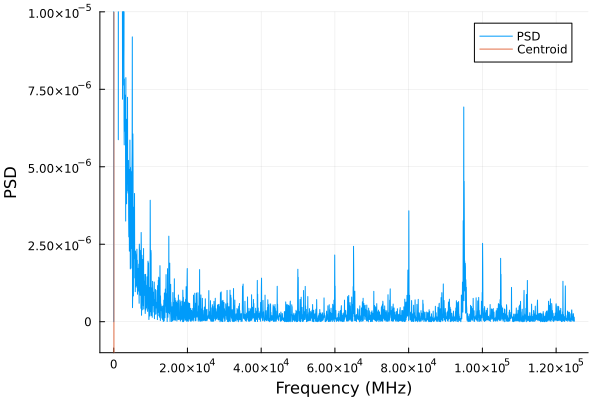

In [13]:
plot(
    fpos .* 1e-6,
    PSD,
    xlabel="Frequency (MHz)",
    ylabel="PSD",
    label="PSD",
    ylim = (-1e-6,1e-5)
)

vline!(
    [fc * 1e-6],
    label="Centroid"
)

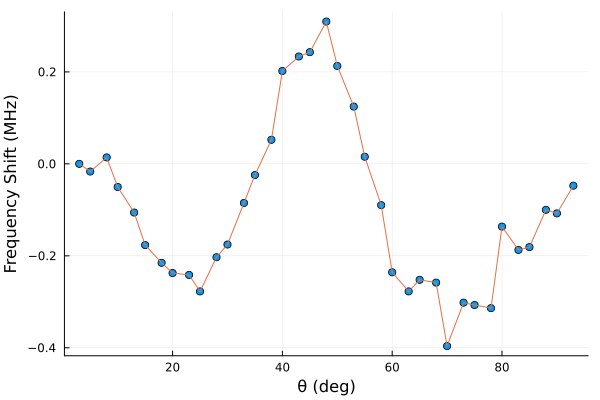

In [14]:
ωref = ω[findfirst(==(3), degs)]

Δω = ω .- ωref

scatter(
    degs,
    Δω .* 1e-6,
    xlabel="θ (deg)",
    ylabel="Frequency Shift (MHz)",
    legend=false
)

plot!(
    degs,
    Δω .* 1e-6
)

In [15]:
θ = deg2rad.(degs)

a_theory = cos.(θ)
b_theory = sin.(θ)

PH_theory = abs2.(a_theory)
PV_theory = abs2.(b_theory)

37-element Vector{Float64}:
 0.0027390523158633317
 0.007596123493895969
 0.019369152030840567
 0.030153689607045803
 0.05060297685041651
 0.06698729810778066
 0.09549150281252627
 0.11697777844051097
 0.15267081477050137
 0.17860619515673035
 0.2204035482646266
 0.24999999999999994
 0.2966316784620999
 ⋮
 0.8213938048432696
 0.8596699001693257
 0.8830222215594888
 0.9145187862775208
 0.9330127018922194
 0.9567727288213004
 0.9698463103929541
 0.9851478631379982
 0.9924038765061041
 0.9987820251299122
 1.0
 0.9972609476841365

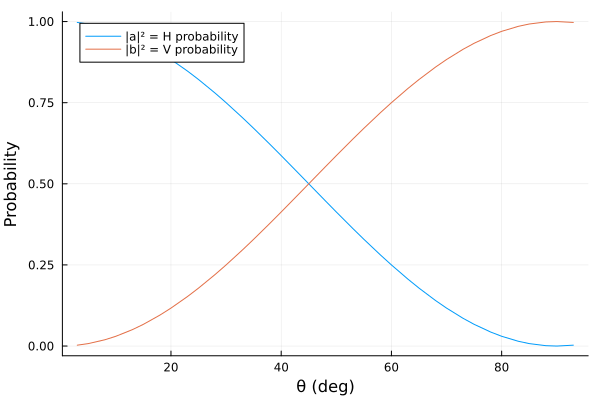

In [16]:
plot(degs, PH_theory, label="|a|² = H probability")
plot!(degs, PV_theory, label="|b|² = V probability")
xlabel!("θ (deg)")
ylabel!("Probability")

In [17]:
ψ_theory = [[a_theory[i], b_theory[i]] for i in eachindex(degs)]

37-element Vector{Vector{Float64}}:
 [0.9986295347545738, 0.052335956242943835]
 [0.9961946980917455, 0.08715574274765817]
 [0.9902680687415704, 0.13917310096006544]
 [0.984807753012208, 0.17364817766693033]
 [0.9743700647852352, 0.224951054343865]
 [0.9659258262890683, 0.25881904510252074]
 [0.9510565162951535, 0.3090169943749474]
 [0.9396926207859084, 0.3420201433256687]
 [0.9205048534524404, 0.39073112848927377]
 [0.9063077870366499, 0.42261826174069944]
 [0.882947592858927, 0.4694715627858908]
 [0.8660254037844387, 0.49999999999999994]
 [0.838670567945424, 0.5446390350150271]
 ⋮
 [0.42261826174069944, 0.9063077870366499]
 [0.37460659341591196, 0.9271838545667874]
 [0.3420201433256688, 0.9396926207859083]
 [0.29237170472273677, 0.9563047559630354]
 [0.25881904510252074, 0.9659258262890683]
 [0.20791169081775945, 0.9781476007338056]
 [0.17364817766693041, 0.984807753012208]
 [0.12186934340514749, 0.992546151641322]
 [0.08715574274765814, 0.9961946980917455]
 [0.03489949670250108, 0.9

In [18]:
# Reference values
t_ref = τ[1]
f_ref = ω[1]

# Shifts
Δt = τ .- t_ref              # seconds
Δf = ω .- f_ref    # Hz

# Convert frequency shift to angular frequency shift
Δω = 2π .* Δf                  # rad/s

# Experimental constants
τ = 5e-12      # example: replace with your coupling delay in seconds
σ = 1e-9       # example: replace with temporal Gaussian width in seconds

# Weak value
Aw = (Δt .+ im .* (Δω ./ (4σ^2))) ./ delay

37-element Vector{ComplexF64}:
                 -0.0 - 0.0im
 0.001919753639195564 + 1.0254278273806418e32im
    0.030027672404407 - 8.587602477127886e31im
 0.026198863656942815 + 3.0855187880038836e32im
  0.05223610051151845 + 6.496318245770795e32im
  0.09098500451917854 + 1.083620420746981e33im
  0.16324651774939267 + 1.3210124184940653e33im
   0.1806058813815678 + 1.456957134049321e33im
   0.2746598705510055 + 1.482405799782843e33im
  0.35539510036237126 + 1.7026212758370944e33im
  0.40489360776919914 + 1.2463482473358243e33im
  0.44734258247059666 + 1.0765463088515627e33im
   0.5258186738786885 + 5.21883640015783e32im
                      ⋮
   0.4619403507759533 + 1.5474967470012413e33im
   0.3858967286046964 + 1.5850921871085118e33im
  0.35496500121412544 + 2.4318429383661852e33im
  0.27864852073084323 + 1.8524888774116377e33im
  0.22190584700075397 + 1.884245341127522e33im
  0.16559013730818067 + 1.9255287773436852e33im
  0.11701810932851962 + 8.372976754012917e32im
  0.07842805

In [19]:
Δt = τ .- t_ref  

-4.886351674268413e-9

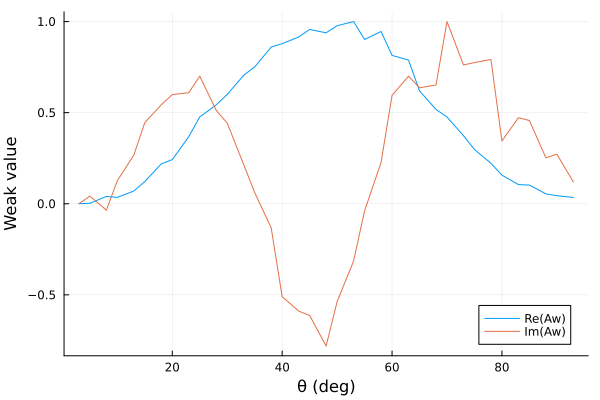

In [27]:
plot(degs, abs.(real.(Aw)./maximum(real.(Aw))), label="Re(Aw)")
plot!(degs, imag.(Aw)./maximum(imag.(Aw)), label="Im(Aw)")
xlabel!("θ (deg)")
ylabel!("Weak value")